Kelompok 2. Rayhan Christian Wewengkang (2024081005) & Azzah Muthia (2024011014).  
Dataset : Car Features and MSRP https://www.kaggle.com/datasets/CooperUnion/cardataset

LIBRARY 

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

Load Datasets

In [17]:
df = pd.read_csv('data.csv')

In [18]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [19]:
# Cek missing values dan info dataset awal
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

## 1. Feature Engineering

Pada tahap ini kita akan melakukan beberapa transformasi data agar lebih siap untuk digunakan dalam pemodelan.
Metode yang akan digunakan:
1. Missing Value Handling
2. Log Transformation
3. One-hot Encoding
4. Scaling

In [20]:
#1.1 Missing Value Handling
# Mengisi nilai kosong (missing values) pada kolom numerik dengan nilai median
for col in ['Engine HP', 'Engine Cylinders', 'Number of Doors']:
    df[col] = df[col].fillna(df[col].median())

# Mengisi nilai kosong pada kolom kategorikal dengan modus (nilai yang paling sering muncul)
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

print("Sisa missing values pada fitur penting:")
print(df[['Engine HP', 'Engine Cylinders', 'Number of Doors', 'Engine Fuel Type']].isnull().sum())

Sisa missing values pada fitur penting:
Engine HP           0
Engine Cylinders    0
Number of Doors     0
Engine Fuel Type    0
dtype: int64


**Penjelasan/Interpretasi**: Kita menggunakan median untuk data numerik karena median lebih tahan terhadap outlier outlier (nilai ekstrem) dibandingkan rata-rata (mean). Untuk tipe bahan bakar (kategorikal), kita gunakan modus karena itu adalah nilai yang paling logis untuk mewakili data kosong.

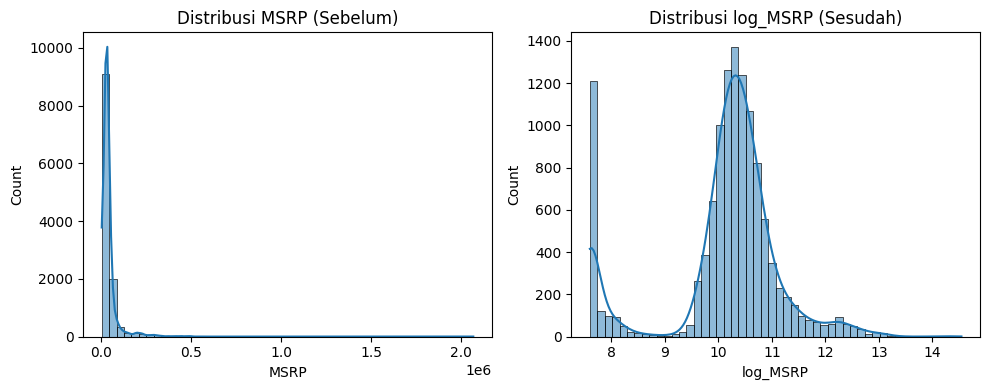

In [21]:
#1.2 Log Transformation
df['log_MSRP'] = np.log1p(df['MSRP'])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['MSRP'], bins=50, kde=True)
plt.title('Distribusi MSRP (Sebelum)')

plt.subplot(1, 2, 2)
sns.histplot(df['log_MSRP'], bins=50, kde=True)
plt.title('Distribusi log_MSRP (Sesudah)')
plt.tight_layout()
plt.show()

**Penjelasan/Interpretasi**: Transformasi Logaritma membantu mengurangi kemiringan (skewness) pada data harga yang sangat bervariasi (dari mobil murah hingga sangat mahal), sehingga model prediksi harga mobil nantinya bisa belajar tanpa bias terhadap harga yang terlalu tinggi.

In [22]:
#1.3 One-Hot Encoding
# Mengubah variabel kategorikal menjadi kolom-kolom biner (0 atau 1)
cat_cols = ['Transmission Type', 'Driven_Wheels']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Kolom setelah One-Hot Encoding:")
print([col for col in df_encoded.columns if 'Transmission' in col or 'Driven_Wheels' in col])

Kolom setelah One-Hot Encoding:
['Transmission Type_AUTOMATIC', 'Transmission Type_DIRECT_DRIVE', 'Transmission Type_MANUAL', 'Transmission Type_UNKNOWN', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive']


**Penjelasan/Interpretasi**: Algoritma machine learning mayoritas hanya bisa menerima input angka. One-hot encoding memecah kolom tipe transmisi atau penggerak roda menjadi beberapa kolom berisi angka 1 (ya) atau 0 (tidak).

In [23]:
#1.4 Scaling
# Memilih fitur numerik yang akan digunakan
num_features = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']
dummy_cols = [col for col in df_encoded.columns if col.startswith(tuple(cat_cols))]
features = num_features + dummy_cols

X = df_encoded[features]
y = df_encoded['log_MSRP']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Data awal (Engine HP):", X['Engine HP'].head(3).values)
print("Data hasil scaling (Engine HP):", X_scaled['Engine HP'].head(3).values)

Data awal (Engine HP): [335. 300. 300.]
Data hasil scaling (Engine HP): [0.7874773  0.46603392 0.46603392]


**Penjelasan/Interpretasi**: Scaling menyeragamkan rentang nilai dari semua fitur numerik. Misalnya `Year` berkisar dalam digit ribuan, sedangkan `Engine Cylinders` hanya 1 digit (contoh: 4 atau 6). Dengan StandardScaler, semua fitur akan diubah sehingga memiliki rata-rata 0 dan standar deviasi 1. Ini penting agar tidak ada satu fitur pun yang mendominasi fitur lainnya dalam pembobotan algoritma, hanya karena angkanya lebih besar.

## 2. Feature Selection

Memilih fitur-fitur yang paling relevan untuk memprediksi harga mobil (`log_MSRP`).
Metode yang digunakan:
1. Correlation Heatmap
2. Univariate Selection (SelectKBest)
3. Recursive Feature Elimination (RFE)

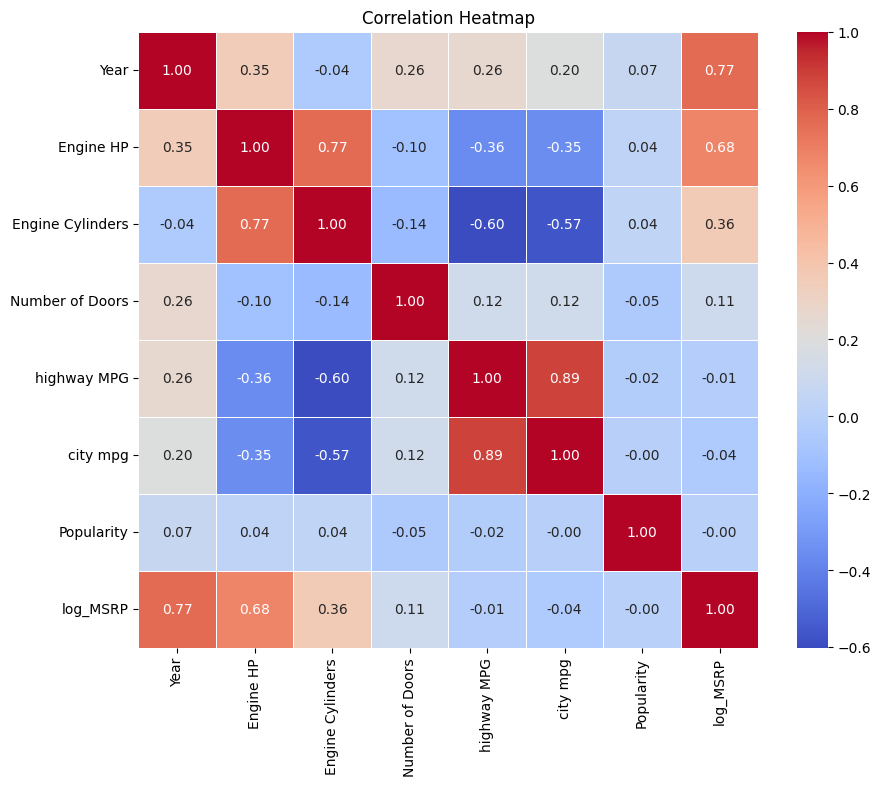

Korelasi masing-masing fitur dengan target (log_MSRP):
log_MSRP            1.000000
Year                0.768124
Engine HP           0.677603
Engine Cylinders    0.356584
Number of Doors     0.108268
Popularity         -0.000419
highway MPG        -0.014452
city mpg           -0.039361
Name: log_MSRP, dtype: float64


In [24]:
#2.1 Correlation Heatmap
# Menggabungkan fitur numerik dan target untuk melihat korelasi linier
numerical_df = df_encoded[num_features + ['log_MSRP']]
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

print("Korelasi masing-masing fitur dengan target (log_MSRP):")
print(corr_matrix['log_MSRP'].sort_values(ascending=False))

**Penjelasan/Interpretasi Heatmap**: Di dalam Heatmap, fitur yang warnanya merah gelap dan mendekati angka 1 memiliki hubungan positif yang kuat dengan harga. Terlihat bahwa `Engine HP` (Tenaga Mesin) dan `Year` (Tahun keluaran) berkorelasi positif sangat kuat dengan `log_MSRP`. Artinya, semakin besar tenaga mesin atau semakin baru tahun mobilnya, harganya berbanding lurus dan cenderung semakin mahal.

In [25]:
#2.2 Univariate Feature Selection (SelectKBest)
# Memilih 5 fitur terbaik berdasarkan uji statistik F-regression
from sklearn.linear_model import LinearRegression
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X_scaled, y)

scores = pd.DataFrame({'Fitur': X.columns, 'Skor_F': selector.scores_})
scores = scores.sort_values(by='Skor_F', ascending=False)

print("5 Fitur terbaik menurut Univariate Selection:")
print(scores.head(5))

5 Fitur terbaik menurut Univariate Selection:
                         Fitur        Skor_F
0                         Year  17142.702923
1                    Engine HP  10112.429429
9     Transmission Type_MANUAL   1805.872839
2             Engine Cylinders   1735.276515
7  Transmission Type_AUTOMATIC    793.130412


**Penjelasan/Interpretasi Univariate**: Metode ini menilai hubungan masing-masing fitur secara individual (sendiri-sendiri) terhadap target kemahalan mobil. Skor uji F (*Skor_F*) yang lebih tinggi menandakan fitur tersebut lebih signifikan dalam menentukan harga mobil. Hasilnya mendukung temuan heatmap, menempatkan `Engine HP` dan `Year` di posisi teratas.

In [26]:
#2.3 Recursive Feature Elimination (RFE)
# Evaluasi fitur dengan menggunakan model regresi secara iteratif membuang fitur terlemah
from sklearn.feature_selection import RFE

lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_scaled, y)

rfe_features = pd.DataFrame({'Fitur': X.columns, 'Terpilih': rfe.support_, 'Ranking': rfe.ranking_})

print("Fitur yang terpilih (Ranking 1) oleh RFE:")
print(rfe_features[rfe_features['Terpilih']].sort_values(by='Ranking'))

Fitur yang terpilih (Ranking 1) oleh RFE:
                         Fitur  Terpilih  Ranking
0                         Year      True        1
1                    Engine HP      True        1
2             Engine Cylinders      True        1
7  Transmission Type_AUTOMATIC      True        1
9     Transmission Type_MANUAL      True        1


**Penjelasan/Interpretasi RFE**: RFE mengeliminasi fitur secara rekursif. Ia mencoba membuat model machine learning dan mengevaluasi bobot keseluruhan (kombinasi) antar fitur, lalu membuang fitur yang memiliki bobot terendah. Fitur yang mendapatkan *Ranking 1* adalah kombinasi 5 fitur terbaik untuk digunakan bersamaan dalam model regresi linear.